In [119]:
!pip install torchtext

In [123]:
import torch 
# import torchtext 
from torch import nn 
import numpy as np 
import math 
from torch.utils.data import DataLoader,dataset

**Encoder with 6 blocks and with 8 attention head**\
**Embedding size = 512** as we are using 8 attention head\
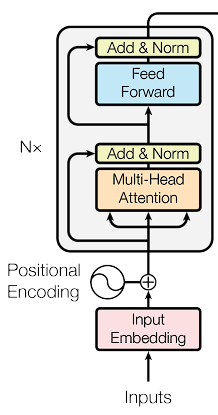

In [43]:
class EncoderBlock(nn.Module):
    def __init__(self,embed_dim,num_head=8):
        super().__init__()
        self.LayerNormalization1 = nn.LayerNorm(embed_dim)
        self.LayerNormalization2 = nn.LayerNorm(embed_dim)
        self.MultiHeadAttention = nn.MultiheadAttention(embed_dim = embed_dim,num_heads=num_head,batch_first=True)
        self.FeedForward = nn.Sequential(
            nn.Linear(embed_dim,2048),
            nn.ReLU(),
            nn.Linear(2048,embed_dim),
            )
    def forward(self,x):
        # Self-Attention block and LayerNorm
        attention_out,_ = self.MultiHeadAttention(x,x,x,need_weights=False)
        normalized_embedding = self.LayerNormalization1(attention_out+x)

        # LayerNorm and Feed Forward
        output = self.FeedForward(normalized_embedding)
        output = self.LayerNormalization2(output+normalized_embedding)

        return output 

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, max_seq_len=1000):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embed_dim,padding_idx=0)
        self.layers = nn.ModuleList(
            [EncoderBlock(embed_dim,num_head=8) for _ in range(6)]
        )

        pe = torch.zeros(max_seq_len, embed_dim)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_dim, 2).float() * (-math.log(10000.0) / embed_dim))
        
        pe[:, 0::2] = torch.sin(position * div_term) 
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) 
        self.register_buffer('pe', pe)

    def forward(self, x):
        # calculating and adding positional encoding
        seq_len = x.size(1)
        embedding = self.embedding(x) 
        embedding = embedding + self.pe[:, :seq_len, :]

        for layer in self.layers:
            output = layer(embedding)
        return output


**Decoder with 6 block and same 8 masked attention head**\
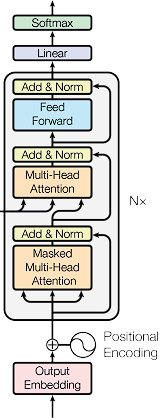


In [171]:
class DecoderBlock(nn.Module):
    def __init__(self,embed_size,num_heads=8):
        super().__init__()
        self.LayerNormalization1 = nn.LayerNorm(embed_size)
        self.LayerNormalization2 = nn.LayerNorm(embed_size)
        self.LayerNormalization3 = nn.LayerNorm(embed_size)

        self.FeedForward = nn.Sequential(
            nn.Linear(embed_size,2048),
            nn.ReLU(),
            nn.Linear(2048,embed_size),
        )

        self.MaskedMultiHeadAttention = nn.MultiheadAttention(embed_dim=embed_size,num_heads=num_heads,batch_first=True)
        self.CrossAttention = nn.MultiheadAttention(embed_dim=embed_size,num_heads=num_heads,batch_first=True)

    def forward(self,x,enc_output, trg_mask):
        # Masked attention and Layer normalization layers
        attention_out,_ = self.MaskedMultiHeadAttention(x,x,x,need_weights=False,attn_mask=trg_mask)
        normalized_out = self.LayerNormalization1(attention_out+x)
        # Cross attention and Layer normalization layers
        attention_out,_ = self.CrossAttention(normalized_out,enc_output,enc_output,need_weights=False)
        normalized_out = self.LayerNormalization2(attention_out+normalized_out)

        # Feed forward network with Layer normalization layers 
        output_logits = self.FeedForward(normalized_out)
        normalized_out = self.LayerNormalization3(output_logits+normalized_out)

        return normalized_out

class Decoder(nn.Module):
    def __init__(self,vocab_size,embed_size,num_heads=8,max_seq_len=1000):
        super().__init__()
        self.embed_size = embed_size
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size,embed_size,padding_idx=0)
        self.layers = nn.ModuleList(
            [DecoderBlock(embed_size,num_heads=num_heads) for _ in range(6)]
        )

        pe = torch.zeros(max_seq_len, embed_size)
        position = torch.arange(0, max_seq_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, embed_size, 2).float() * (-math.log(10000.0) / embed_size))
        
        pe[:, 0::2] = torch.sin(position * div_term) 
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0) 
        self.register_buffer('pe', pe)

    def get_trg_mask(self,size):
        mask = torch.triu(torch.ones((size, size)), diagonal=1).bool()
        return mask
        
    def forward(self,x):
        # calculating and adding positional encoding
        seq_len = x.size(1)
        embedding = self.embedding(x) 
        embedding = embedding + self.pe[:, :seq_len, :]

        # creating Key and value vectors to pass into cross attention block 
        # enc_output = torch.zeros(size=(x.size(0),x.size(1),self.embed_size)) 

        encoder = Encoder(self.vocab_size, self.embed_size)
        enc_output = encoder(x)
       
        # creating masked matrix for passing into masked attention block
        trg_mask = self.get_trg_mask(x.size(1))

        for layer in self.layers:
            output = layer(embedding,enc_output, trg_mask) 
        return output

In [172]:
VOCAB_SIZE = 100
EMBEDDING_SIZE = 512 
SEQ_LENGTH = 10
BATCH_SIZE = 32

input_tensor = torch.randint(0,VOCAB_SIZE,size=(BATCH_SIZE,SEQ_LENGTH),dtype=torch.long)
# input_tensor
Model = Decoder(VOCAB_SIZE,EMBEDDING_SIZE)
output = Model(input_tensor)
print(output.shape)

torch.Size([32, 10, 512])


In [125]:
import kagglehub
path = kagglehub.dataset_download("shahadhamza/multi30k-dataset")
print("Path to dataset files:", path)

Using Colab cache for faster access to the 'multi30k-dataset' dataset.
Path to dataset files: /kaggle/input/multi30k-dataset


In [139]:
en_path = "/kaggle/input/multi30k-dataset/train.en"
fr_path = "/kaggle/input/multi30k-dataset/train.fr"

In [141]:
with open(en_path,'r') as file:
    train_list_en = file.readlines()
with open(fr_path,'r') as file:
    train_list_fr = file.readlines()

print(len(train_list_en))
print(len(train_list_fr))

29000
29000
